# SINABS Transfer
In this notebook we will be taking a look at an end to end example of transfering a trained normal SPICEnet implementation to our new SINABS specific implementation via NIR.

We will start the notebook as normal by training a simple spice_net on the test data.

In [1]:
import numpy as np
import pandas as pd

import spice_net as spn

In [2]:
df = pd.read_csv('data/test_data.csv')
df

,init,result
0,-0.868245,-0.654525
1,0.866917,0.651528
2,-0.102037,-0.001062
3,0.602888,0.219135
4,0.838314,0.589141
...,...,...
2995,-0.181318,-0.005961
2996,0.314093,0.030987
2997,-0.313361,-0.030771
2998,0.144365,0.003009


In [3]:
som_size = 100

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=df['init'].min(),
                        value_range_end=df['init'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))
som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        value_range_start=df['result'].min(),
                        value_range_end=df['result'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm(som_1, som_2, spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [4]:
spice_net.fit(df['init'].tolist(), df['result'].tolist(), 10, 100, print_output=True)

100%|██████████| 30/30 [00:21<00:00,  1.39it/s]

Time spend on the Components: 
Som: 14.097878217697144 s | Convolution Matrix: 7.400481462478638 s


In [5]:
# Print som neuron tuning curve width
min_width = 100
max_width = 0

for neuron in som_1.neurons:
    if neuron.tuning_curve_width < min_width:
        min_width = neuron.tuning_curve_width
    if neuron.tuning_curve_width > max_width:
        max_width = neuron.tuning_curve_width
    
for neuron in som_2.neurons:
    if neuron.tuning_curve_width < min_width:
        min_width = neuron.tuning_curve_width
    if neuron.tuning_curve_width > max_width:
        max_width = neuron.tuning_curve_width


In [6]:
min_width

np.float64(0.0017156157308674494)

In [7]:
max_width

np.float64(0.03312830616525595)

## SINABS SOM Neuron
We do some exploration utilizing the new SOM Neuron implementations.

Our implementation is a nn.Module class that takes two parameters for tuning curve width/standard deviation and preferred value athat it will pass with the input value given for every timestep.
It furthermore takes the timesteps as a parameter to convert our pre-trained model to the correct time step parameter model for every case.

In [8]:
from sinabs.spicenet.som_neuron import SpiceSOMNeuron
from sinabs.nir import from_nir
from spice_net.utility.nir_utils import *

som_1_nir_neuron = som_neuron_to_nir(som_1.neurons[50])

som_neuron = from_nir(som_1_nir_neuron)

AttributeError: 'SPICEnetSOMNeuron' object has no attribute 'nodes'

In [ ]:
import torch

# The neuron takes single 1D tensor as input and outputs the resulting timesteps for each timestep for each value in the input tensor
results = som_neuron(torch.Tensor([0.1, 0.2, 1, 0.1]))
results

torch.Size([4, 3])
torch.Size([100, 4, 3])


tensor([[[ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02]],

        [[ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02]],

        [[ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02],
         [ 4.5391e-02]],

        [[ 4.5391e-02],
         [ 4.5391e-02],
         [ 1.6259e+00],
         [ 4.5391e-02]],

        [[ 4.5391e-02],
         [ 4.5391e-02],
         [ 1.8321e+00],
         [ 4.5391e-02]],

        [[-2.6741e-02],
         [-2.6741e-02],
         [ 7.3117e+00],
         [-2.6741e-02]],

        [[ 1.2165e-02],
         [ 4.5391e-02],
         [ 8.4084e+00],
         [ 1.2165e-02]],

        [[ 2.0081e-02],
         [-1.3145e-02],
         [ 1.8730e+00],
         [ 2.0081e-02]],

        [[-8.2032e-03],
         [-9.0491e-03],
         [ 3.4677e+00],
         [-8.2032e-03]],

        [[ 3.0085e-02],
         [ 5.0652e-02],
         [ 3.5817e+00],
         [ 3.0085e-02]],

        [[-2.1338e-0

In [9]:
def gauss_pdf(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2))

In [10]:
gauss_pdf(0.1, 1, 0.0017156157308674494)

np.float64(0.0)

In [11]:
gauss_pdf(0.2, 1, 0.0017156157308674494)

np.float64(0.0)

In [12]:
gauss_pdf(1, 1, 0.0017156157308674494)

np.float64(232.53591886786882)

In [13]:
# Average SNN Neuron results over last 50 time steps

result_one = results[50:, 0, :].mean().item()
result_two = results[50:, 1, :].mean().item()
result_three = results[50:, 2, :].mean().item()

In [14]:
result_one, result_two, result_three

(-0.060103364288806915, -0.08878672868013382, 4.1274518966674805)

In [15]:
0.1 / 0.0017156157308674494

58.28811091015003

In [ ]:
# Speculation: can maybe get closer to the real result by multiplying the result with the ratio of our trained min std to the real min std.
# Training for lower std is underway but struggles with high values and accuracy.
result_one * 58.28811091015003, result_two * 58.28811091015003, result_three * 58

(-3.5033115637391283, -5.175210688657039, 239.39221000671387)

In [ ]:
# Helper implementation for first tests: The real implementation optimizes this by only utilizing one single neuron for each SOM to save resources
class SNNSom:
    def __init__(self, som, timesteps):
        self.som_size = len(som.neurons)
        self.timesteps = timesteps  
        
        self.neurons = []
        
        for neuron in som.neurons:
            self.neurons.append(SpiceSOMNeuron(neuron.tuning_curve_width, neuron.preferred_value, timesteps))
    
    def get_activation_vector(self, value):
        results = []
        
        if isinstance(value, list):
            for neuron in self.neurons:
                results_values = neuron(torch.Tensor(value))
                subresult = []
                for i in range(len(value)):
                    subresult.append(results_values[50:, i, :].mean().item())
                results.append(subresult)
        else:
            for neuron in self.neurons:
                results.append(neuron(torch.Tensor([value]))[50:, 0, :].mean().item())
        
        return results

In [18]:
snn_som = SNNSom(som=som_1, timesteps=100)

In [19]:
normal_som_result = som_1.get_activation_vector(0.4)
len(normal_som_result)

100

In [20]:
snn_som_response = snn_som.get_activation_vector(0.4)
len(snn_som_response)

torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size(

100

In [21]:
winner_neuron = np.argmax(snn_som_response)
winner_neuron

np.int64(72)

In [22]:
winner_neuron_normal_som = np.argmax(normal_som_result)
winner_neuron_normal_som

np.int64(71)

In [23]:
sorted_normal_response_with_index = sorted(enumerate(normal_som_result), key=lambda x: x[1], reverse=True)
sorted_snn_response_with_index = sorted(enumerate(snn_som_response), key=lambda x: x[1], reverse=True)

for i in range(100):
    print(sorted_normal_response_with_index[i], sorted_snn_response_with_index[i])

(71, np.float64(22.106624043160142)) (72, 4.204968452453613)
(72, np.float64(9.509298014529898)) (70, 4.090519428253174)
(70, np.float64(7.4767394432280065)) (71, 4.064678192138672)
(73, np.float64(0.9057188265060123)) (73, 4.0102410316467285)
(69, np.float64(0.3685873106819775)) (74, 3.8576877117156982)
(74, np.float64(0.017094873184707194)) (69, 3.853703022003174)
(68, np.float64(2.7546944547191967e-05)) (68, 3.3160147666931152)
(75, np.float64(1.5665379570792197e-07)) (75, 3.1419689655303955)
(66, np.float64(9.340751727746959e-12)) (67, 2.8905487060546875)
(67, np.float64(4.150156700801581e-12)) (76, 2.66568660736084)
(77, np.float64(1.2654178978534373e-13)) (77, 2.6563799381256104)
(76, np.float64(3.708426860284666e-16)) (66, 2.635861873626709)
(65, np.float64(2.5799769359993945e-16)) (65, 2.1880533695220947)
(64, np.float64(1.8324603890425476e-20)) (78, 2.1120188236236572)
(78, np.float64(3.1204512827853834e-22)) (64, 1.2448670864105225)
(79, np.float64(1.5052661960990416e-26)) (8

In [24]:
# Find matches in top 25
top_25_normal = [x[0] for x in sorted_normal_response_with_index[:25]]
top_25_snn = [x[0] for x in sorted_snn_response_with_index[:25]]

matches = 0

for i in range(25):
    if top_25_normal[i] in top_25_snn:
        matches += 1
matches

21

In [25]:
# Matches in top 50
top_50_normal = [x[0] for x in sorted_normal_response_with_index[:50]]
top_50_snn = [x[0] for x in sorted_snn_response_with_index[:50]]

matches = 0

for i in range(50):
    if top_50_normal[i] in top_50_snn:
        matches += 1
        
matches

29

In [26]:
# Exact matches top 25
matches = 0

for i in range(25):
    if sorted_normal_response_with_index[i][0] == sorted_snn_response_with_index[i][0]:
        matches += 1
matches

5

In [27]:
# For the first 100 init entry compare the winner neuron
winner_neurons_normal = []
winner_neurons_snn = []

for value in df['init'][:100]:
    winner_neurons_normal.append(np.argmax(som_1.get_activation_vector(value)))
    winner_neurons_snn.append(np.argmax(snn_som.get_activation_vector(value)))
    
# Do the same for som_2
snn_som_2 = SNNSom(som=som_2, timesteps=100)

winner_neurons_normal_2 = []
winner_neurons_snn_2 = []

for value in df['result'][:100]:
    winner_neurons_normal_2.append(np.argmax(som_2.get_activation_vector(value)))
    winner_neurons_snn_2.append(np.argmax(snn_som_2.get_activation_vector(value)))


torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size([1, 3])
torch.Size([100, 1, 3])
torch.Size(

In [28]:
# Get diff per entry between norm and snn
som_1_diff = [abs(x - y) for x, y in zip(winner_neurons_normal, winner_neurons_snn)]
som_2_diff = [abs(x - y) for x, y in zip(winner_neurons_normal_2, winner_neurons_snn_2)]

In [29]:
np.mean(som_1_diff), np.mean(som_2_diff)

(np.float64(0.64), np.float64(1.65))

In [36]:
# Now we do it batched

# For the first 100 init entry compare the winner neuron
winner_neurons_normal = []
winner_neurons_snn = []

for value in df['init'][:100]:
    winner_neurons_normal.append(np.argmax(som_1.get_activation_vector(value)))
print(df['init'][:100].to_list())
result = snn_som.get_activation_vector(df['init'][:100].to_list())
print(result)



[-0.8682447826250757, 0.866917431928073, -0.1020374904369925, 0.6028884400960157, 0.8383135643311708, 0.5096444988718252, -0.3071024726547451, -0.1370243087487783, -0.2508260279179017, -0.7856101621547595, -0.2236179997432437, 0.6559479066568092, 0.2505528473238594, 0.6744674309834453, -0.3776247958387329, 0.8496892275392962, -0.6371244540477354, -0.9409190105180608, 0.1213660705943369, 0.1866987750359596, 0.8139410266435063, -0.046475548908389, -0.1695601973054761, -0.954190116101316, -0.8532405462085937, 0.5979964827255073, -0.8442567872798592, -0.0580141505435471, -0.8557086534078719, 0.6806645380854803, -0.2535023133860417, 0.8812045723135709, 0.0721964052366668, -0.5524091777815572, -0.3719557870641672, -0.621141857530054, -0.1483048309712282, -0.2502121703214826, -0.5595615495074293, -0.489294717056197, -0.9637121602828806, -0.0016140491132725, -0.3087613030098239, -0.3623571873708642, -0.0808641360583914, 0.8060280503103872, -0.4587911747487518, 0.1510412466791866, 0.17426673069

In [ ]:
result_tensor = torch.Tensor(result).T
result_tensor.shape


torch.Size([100, 100])

In [37]:
winner_neurons_snn = torch.argmax(result_tensor, dim=1).tolist()
winner_neurons_snn

[7,
 94,
 46,
 83,
 92,
 76,
 35,
 43,
 36,
 12,
 37,
 85,
 65,
 86,
 31,
 94,
 19,
 2,
 58,
 60,
 90,
 51,
 41,
 0,
 8,
 83,
 8,
 50,
 7,
 87,
 36,
 95,
 54,
 21,
 31,
 19,
 43,
 38,
 22,
 25,
 1,
 52,
 34,
 31,
 47,
 91,
 26,
 59,
 60,
 9,
 78,
 32,
 60,
 24,
 38,
 57,
 8,
 14,
 82,
 94,
 56,
 66,
 72,
 91,
 94,
 83,
 72,
 56,
 5,
 63,
 71,
 36,
 98,
 53,
 32,
 2,
 74,
 30,
 59,
 56,
 66,
 16,
 9,
 60,
 43,
 53,
 20,
 91,
 65,
 52,
 36,
 84,
 63,
 65,
 16,
 38,
 66,
 4,
 93,
 36]

In [43]:
   
# Do the same for som_2
snn_som_2 = SNNSom(som=som_2, timesteps=100)

winner_neurons_normal_2 = []
winner_neurons_snn_2 = []

for value in df['result'][:100]:
    winner_neurons_normal_2.append(np.argmax(som_2.get_activation_vector(value)))
result_two = snn_som_2.get_activation_vector(df['result'][:100].to_list())

torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([1

In [44]:
result_two_tensor = torch.Tensor(result).T
print(result_two_tensor.shape)
winner_neurons_snn_2 = torch.argmax(result_two_tensor, dim=1).tolist()


torch.Size([100, 100])


In [45]:
# Get abs diff
som_1_diff = [abs(x - y) for x, y in zip(winner_neurons_normal, winner_neurons_snn)]
som_2_diff = [abs(x - y) for x, y in zip(winner_neurons_normal_2, winner_neurons_snn_2)]
print(som_1_diff)
print(som_2_diff)

[np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1)

In [46]:
# get mean diff
np.mean(som_1_diff), np.mean(som_2_diff)

(np.float64(0.58), np.float64(9.7))

## SINABS SOM
After some exploration into the singular SOM Neuron results we want to explore our new SINABS SOM nn.Module.
It is resource optimized in the sense, that we only load one single SNN model to approximate the neuron calculation for each SOM.
It largly mirrors the original implementation in code, adapted to fit the new SNN Neuron.

The Goal of this section is to explore how accurate the SOM can guess winner neurons and their values, while we have alread seen some of this above we can more easily compare it with our SOM implementation due to the efficiency.

We can also then analyse if fitting the SOM still works relatively well with some more inaccuracys. For this the learning code is ONLY implemented with a constant learning rate able to be given on construction.

In [ ]:
import torch
from sinabs.spicenet.spice_som import SpiceSOM

std_list_som_1 = []
std_list_som_2 = []
pref_list_som_1 = []
pref_list_som_2 = []

for neuron in som_1.neurons:
    std_list_som_1.append(neuron.tuning_curve_width)
    pref_list_som_1.append(neuron.preferred_value)
    
for neuron in som_2.neurons:
    std_list_som_2.append(neuron.tuning_curve_width)
    pref_list_som_2.append(neuron.preferred_value)
    
som_1_spice_snn = SpiceSOM.from_lists(std_list_som_1, pref_list_som_1, df["init"].min(), df["init"].max(), 0.8, 0.8, 100)
som_2_spice_snn = SpiceSOM.from_lists(std_list_som_2, pref_list_som_2, df["result"].min(), df["result"].max(), 0.8, 0.8, 100)

In [ ]:
result_som_1_test = som_1_spice_snn(torch.Tensor([0.4, 0.1]))

torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])


In [10]:
result_som_1_test

tensor([[[[ 0.0454],
          [ 0.0454],
          [ 0.0454],
          ...,
          [ 0.0454],
          [ 0.0454],
          [ 0.0454]],

         [[ 0.0454],
          [ 0.0454],
          [ 0.0454],
          ...,
          [ 0.0454],
          [ 0.0454],
          [ 0.0454]],

         [[ 0.0454],
          [ 0.0454],
          [ 0.0454],
          ...,
          [ 0.0454],
          [ 0.0454],
          [ 0.0454]],

         ...,

         [[ 0.0465],
          [ 0.1076],
          [-0.0272],
          ...,
          [ 0.0442],
          [-0.0185],
          [-0.0694]],

         [[-0.0305],
          [-0.0395],
          [-0.0545],
          ...,
          [ 0.0199],
          [-0.1058],
          [-0.1769]],

         [[ 0.0845],
          [ 0.1404],
          [-0.1880],
          ...,
          [-0.0019],
          [ 0.0226],
          [ 0.0117]]],


        [[[-0.2360],
          [-0.1794],
          [ 0.1007],
          ...,
          [-0.2475],
          [-0.6286],
     

In [11]:
result_som_1_test.shape

torch.Size([2, 100, 100, 1])

In [12]:
# Shape: [input, timesteps, neuron, 1]
result_som_1_test[1, 50:, 56, 0].mean().item()

4.3502421379089355

In [13]:
som_1.get_activation_vector(0.1)[56]

np.float64(12.154893413771845)

In [14]:
# Get winner neuron and value
for i in range(2):
    winner_neuron = torch.argmax(result_som_1_test[i, 50:, :, 0].mean(dim=0)).item()
    print(winner_neuron)

72
56


In [15]:
result_som_1_test[0, 50:, 72, 0].mean(dim=0).item()

4.204968452453613

In [16]:
# Test for all values in the dataset batched by 1000s

winner_neurons_normal = []
winner_neurons_values_normal = []
activations_normal = []
winner_neurons_snn = []
winner_neurons_values_snn = []
activations_snn = []

result = som_1_spice_snn(torch.Tensor(df["init"].tolist()))
for i in range(len(df["init"])):
    _winner_neuron_values = result[i, 40:, :, 0].mean(dim=0)
    _winner_neuron_index = torch.argmax(_winner_neuron_values).item()
    winner_neurons_snn.append(_winner_neuron_index)
    winner_neurons_values_snn.append(_winner_neuron_values[_winner_neuron_index].item())
    activations_snn.append(_winner_neuron_values.tolist())
for value in df['init']:
    _winner_neuron_values = som_1.get_activation_vector(value)
    _winner_neuron_index = np.argmax(_winner_neuron_values)
    winner_neurons_normal.append(_winner_neuron_index)
    winner_neurons_values_normal.append(_winner_neuron_values[_winner_neuron_index])
    activations_normal.append(_winner_neuron_values)


torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torc

In [17]:
winner_neurons_normal

[np.int64(5),
 np.int64(94),
 np.int64(45),
 np.int64(83),
 np.int64(93),
 np.int64(76),
 np.int64(35),
 np.int64(43),
 np.int64(36),
 np.int64(11),
 np.int64(37),
 np.int64(85),
 np.int64(64),
 np.int64(86),
 np.int64(30),
 np.int64(93),
 np.int64(19),
 np.int64(2),
 np.int64(57),
 np.int64(60),
 np.int64(91),
 np.int64(49),
 np.int64(41),
 np.int64(1),
 np.int64(7),
 np.int64(83),
 np.int64(8),
 np.int64(48),
 np.int64(6),
 np.int64(86),
 np.int64(36),
 np.int64(95),
 np.int64(55),
 np.int64(22),
 np.int64(31),
 np.int64(20),
 np.int64(42),
 np.int64(36),
 np.int64(21),
 np.int64(25),
 np.int64(1),
 np.int64(51),
 np.int64(34),
 np.int64(31),
 np.int64(46),
 np.int64(91),
 np.int64(26),
 np.int64(59),
 np.int64(59),
 np.int64(9),
 np.int64(78),
 np.int64(32),
 np.int64(61),
 np.int64(23),
 np.int64(37),
 np.int64(56),
 np.int64(6),
 np.int64(15),
 np.int64(81),
 np.int64(94),
 np.int64(55),
 np.int64(66),
 np.int64(72),
 np.int64(91),
 np.int64(93),
 np.int64(82),
 np.int64(71),
 np.

In [18]:
winner_neurons_snn

[7,
 94,
 44,
 83,
 93,
 77,
 36,
 42,
 36,
 12,
 37,
 85,
 64,
 86,
 30,
 92,
 19,
 2,
 57,
 60,
 91,
 51,
 42,
 2,
 7,
 83,
 8,
 50,
 8,
 87,
 36,
 94,
 54,
 23,
 31,
 20,
 43,
 36,
 22,
 25,
 1,
 52,
 35,
 31,
 47,
 91,
 27,
 59,
 60,
 10,
 78,
 33,
 61,
 24,
 37,
 56,
 8,
 14,
 79,
 92,
 56,
 66,
 73,
 91,
 94,
 83,
 72,
 56,
 7,
 61,
 70,
 36,
 98,
 53,
 32,
 2,
 74,
 31,
 59,
 56,
 65,
 16,
 9,
 60,
 43,
 53,
 21,
 90,
 64,
 52,
 36,
 83,
 64,
 65,
 16,
 37,
 65,
 3,
 92,
 36,
 21,
 19,
 87,
 11,
 9,
 52,
 95,
 9,
 80,
 61,
 95,
 20,
 64,
 55,
 32,
 78,
 52,
 1,
 54,
 47,
 2,
 60,
 66,
 32,
 35,
 93,
 56,
 53,
 28,
 25,
 26,
 95,
 79,
 65,
 1,
 13,
 2,
 19,
 89,
 88,
 66,
 20,
 65,
 78,
 89,
 90,
 5,
 95,
 27,
 29,
 2,
 41,
 53,
 36,
 2,
 66,
 44,
 19,
 20,
 83,
 95,
 21,
 0,
 69,
 15,
 88,
 98,
 1,
 89,
 89,
 99,
 13,
 74,
 21,
 55,
 56,
 95,
 29,
 89,
 15,
 69,
 0,
 51,
 20,
 24,
 14,
 78,
 13,
 1,
 13,
 55,
 14,
 15,
 2,
 98,
 25,
 76,
 28,
 87,
 44,
 99,
 32,
 2,
 69,
 55,
 3

In [19]:
# Get abs diff
som_1_diff = [abs(x - y) for x, y in zip(winner_neurons_normal, winner_neurons_snn)]
np.mean(som_1_diff)

np.float64(0.548)

3000
3000


(array([1587.,    0.,    0., 1192.,    0.,    0.,  211.,    0.,    0.,
          10.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

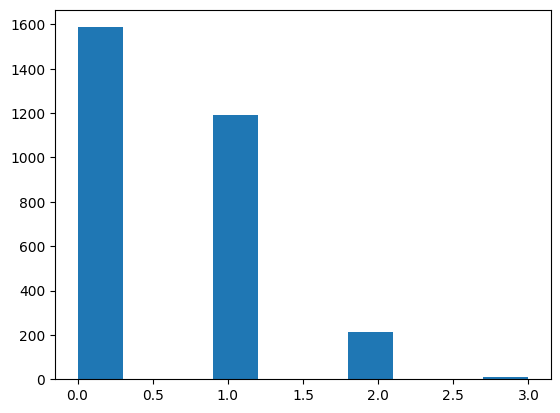

In [20]:
# Plot the diff values counted for each unique diff. The diff can only be int.
import matplotlib.pyplot as plt

print(len(df['init']))
print(len(som_1_diff))
plt.hist(som_1_diff)

In [21]:
abs_diff = []
abs_diff_to_real = []
abs_diff_original_to_real = []
snn_decode = []
normal_decode = []

for i in range(len(winner_neurons_snn)):
    # Compare decode results
    try:
        som1_som2 = correlation_matrix.calculate_som_1_to_2(activations_normal[i])
        _winner_neuron = np.argmax(som1_som2)
        normal_result = som_2.naive_decode(som1_som2[_winner_neuron], _winner_neuron)

        som1_som2 = correlation_matrix.calculate_som_1_to_2(np.array(activations_snn[i]))
        _winner_neuron = np.argmax(som1_som2)
        snn_result = som_2.naive_decode(som1_som2[_winner_neuron], _winner_neuron)
        
        abs_diff.append(abs(normal_result - snn_result))
        abs_diff_to_real.append(abs(df["result"][i] - snn_result))
        abs_diff_original_to_real.append(abs(df["result"][i] - normal_result))
        snn_decode.append(snn_result)
        normal_decode.append(normal_result)
        #print(f"Normal: {normal_result}, SNN: {snn_result}, SpiceNet Decode: {spice_net.decode(df["init"][i])}, Abs diff: {abs_diff[-1]}")
    except Exception:
        print(f"Error at index {i}")
    
np.mean(abs_diff)

# MSE between decode results and original
!pip install scikit-learn
from sklearn.metrics import mean_squared_error

print(f"SNN MSE to Real: {mean_squared_error(df["result"].drop(df["result"].index[[458, 820, 1185, 1442]]), snn_decode)}")
print(f"Normal MSE to Real: {mean_squared_error(df["result"].drop(df["result"].index[[458, 820, 1185, 1442]]), normal_decode)}")

Error at index 458
Error at index 820
Error at index 1185
Error at index 1442



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


SNN MSE to Real: 0.010482558228406614
Normal MSE to Real: 0.0016277640765306614


(array([2342.,  243.,   99.,    6.,   78.,   65.,  144.,    7.,    8.,
           4.]),
 array([1.27022558e-08, 4.49890395e-02, 8.99780662e-02, 1.34967093e-01,
        1.79956120e-01, 2.24945146e-01, 2.69934173e-01, 3.14923200e-01,
        3.59912227e-01, 4.04901253e-01, 4.49890280e-01]),
 <BarContainer object of 10 artists>)

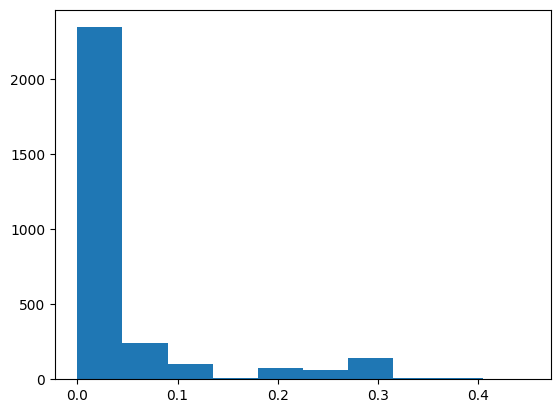

In [22]:
# Plot the abs diff as histogram
plt.hist(abs_diff)

(array([2005.,  304.,  219.,  116.,   78.,   63.,   60.,   52.,   53.,
          46.]),
 array([1.06143651e-05, 3.89911437e-02, 7.79716730e-02, 1.16952202e-01,
        1.55932732e-01, 1.94913261e-01, 2.33893790e-01, 2.72874319e-01,
        3.11854849e-01, 3.50835378e-01, 3.89815907e-01]),
 <BarContainer object of 10 artists>)

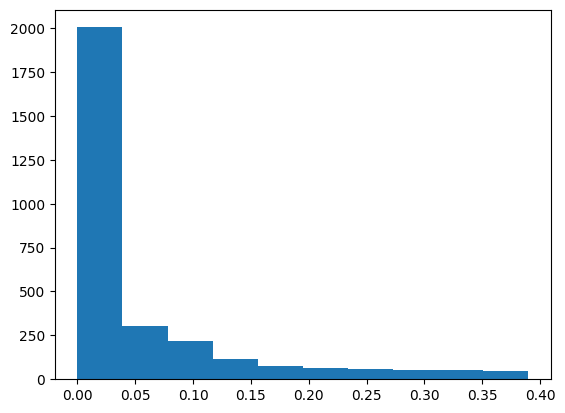

In [23]:
plt.hist(abs_diff_to_real)

(array([2257.,  533.,  147.,   50.,    9.,    0.,    0.,    0.,    0.,
           0.]),
 array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ]),
 <BarContainer object of 10 artists>)

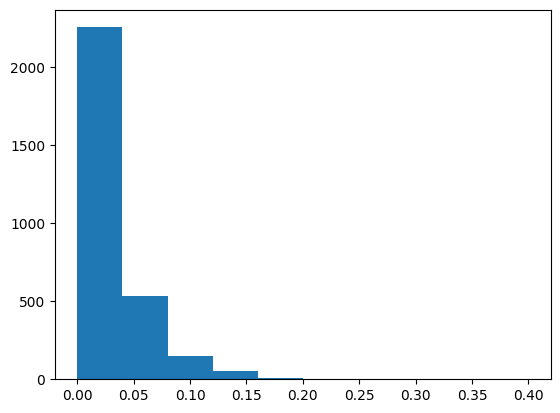

In [24]:
plt.hist(abs_diff_original_to_real, range=(0, 0.40))

In [25]:
# Do similar for som_2
winner_neurons_normal = []
winner_neurons_values_normal = []
activations_normal = []
winner_neurons_snn = []
winner_neurons_values_snn = []
activations_snn = []

result = som_2_spice_snn(torch.Tensor(df["result"].tolist()))
for i in range(len(df["result"])):
    _winner_neuron_values = result[i, 40:, :, 0].mean(dim=0)
    _winner_neuron_index = torch.argmax(_winner_neuron_values).item()
    winner_neurons_snn.append(_winner_neuron_index)
    winner_neurons_values_snn.append(_winner_neuron_values[_winner_neuron_index].item())
    activations_snn.append(_winner_neuron_values.tolist())
    
for value in df['result']:
    _winner_neuron_values = som_2.get_activation_vector(value)
    _winner_neuron_index = np.argmax(_winner_neuron_values)
    winner_neurons_normal.append(_winner_neuron_index)
    winner_neurons_values_normal.append(_winner_neuron_values[_winner_neuron_index])
    activations_normal.append(_winner_neuron_values)
    
# Get abs diff
som_2_diff = [abs(x - y) for x, y in zip(winner_neurons_normal, winner_neurons_snn)]
np.mean(som_2_diff)

torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torch.Size([100, 100, 1])
torch.Size([100, 3])
torch.Size([100, 100, 3])
torc

np.float64(1.3596666666666666)

In [26]:
abs_diff = []
abs_diff_to_real = []
abs_diff_original_to_real = []
snn_decode = []
normal_decode = []

for i in range(len(winner_neurons_snn)):
    # Compare decode results
    try:
        som2_som1 = correlation_matrix.calculate_som_2_to_1(activations_normal[i])
        _winner_neuron = np.argmax(som2_som1)
        normal_result = som_1.naive_decode(som2_som1[_winner_neuron], _winner_neuron)

        som2_som1 = correlation_matrix.calculate_som_1_to_2(np.array(activations_snn[i]))
        _winner_neuron = np.argmax(som2_som1)
        snn_result = som_1.naive_decode(som2_som1[_winner_neuron], _winner_neuron)
        
        abs_diff.append(abs(normal_result - snn_result))
        abs_diff_to_real.append(abs(df["init"][i] - snn_result))
        abs_diff_original_to_real.append(abs(df["init"][i] - normal_result))
        snn_decode.append(snn_result)
        normal_decode.append(normal_result)
        #print(f"Normal: {normal_result}, SNN: {snn_result}, SpiceNet Decode: {spice_net.decode(som_2_value=df["result"][i])}, ABS Diff: {abs_diff[-1]}")
    except Exception:
        print(f"Error at index {i}")
    
np.mean(abs_diff)

# MSE between decode results and original
print(f"SNN MSE to Real: {mean_squared_error(df["init"].drop(df["init"].index[[458, 820, 1185, 1442]]), snn_decode)}")
print(f"Normal MSE to Real: {mean_squared_error(df["init"].drop(df["init"].index[[458, 820, 1185, 1442]]), normal_decode)}")

Error at index 458
Error at index 820
Error at index 1185
Error at index 1442
SNN MSE to Real: 0.14060050218105882
Normal MSE to Real: 0.005712786707035601


(array([1082.,  907.,  401.,    0.,  262.,  196.,    0.,  114.,   36.,
           2.]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 <BarContainer object of 10 artists>)

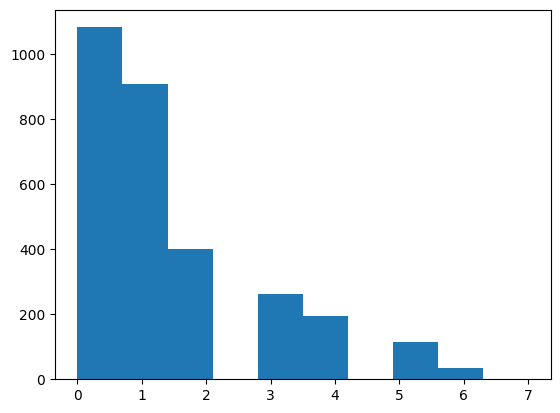

In [27]:
plt.hist(som_2_diff)

(array([598., 109., 182., 195., 278., 251., 196., 741., 329., 117.]),
 array([1.21519731e-04, 7.03466557e-02, 1.40571792e-01, 2.10796928e-01,
        2.81022064e-01, 3.51247200e-01, 4.21472336e-01, 4.91697472e-01,
        5.61922608e-01, 6.32147744e-01, 7.02372880e-01]),
 <BarContainer object of 10 artists>)

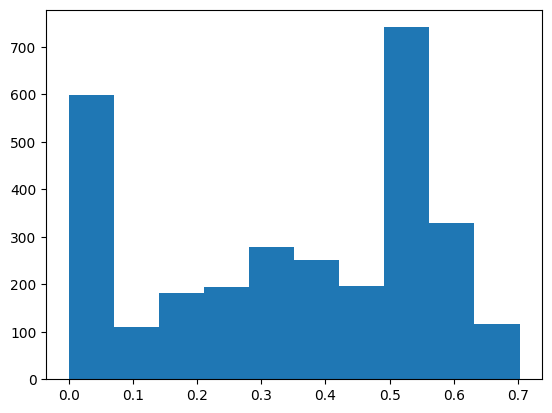

In [28]:
plt.hist(abs_diff)

(array([278., 274., 197., 257., 211., 186., 242., 229., 603., 519.]),
 array([2.01514781e-04, 5.75511613e-02, 1.14900808e-01, 1.72250454e-01,
        2.29600101e-01, 2.86949747e-01, 3.44299394e-01, 4.01649040e-01,
        4.58998687e-01, 5.16348333e-01, 5.73697980e-01]),
 <BarContainer object of 10 artists>)

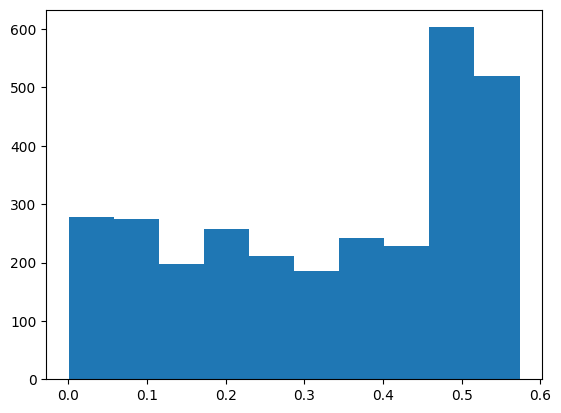

In [29]:
plt.hist(abs_diff_to_real)

(array([2209.,  449.,  194.,   95.,   49.,    0.,    0.,    0.,    0.,
           0.]),
 array([0.  , 0.06, 0.12, 0.18, 0.24, 0.3 , 0.36, 0.42, 0.48, 0.54, 0.6 ]),
 <BarContainer object of 10 artists>)

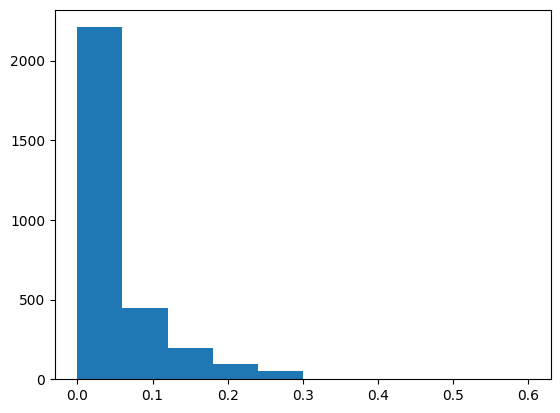

In [30]:
plt.hist(abs_diff_original_to_real, range=(0, 0.6))

We can see that the the first SOM is correct most of the time with a mean winner neuron index error of ~0.5. Additionally, although it translates to much lower activity values, it still performs relatively okay when reconstructing 

However SOM 2 is a different story and for a yet unknown reason performs much worse.

We also want to see how the fitting ens up working, as such we will be running the fitting cycle on one of each, one new original SOM and one new SNN SOM

In [8]:
import time
from typing import Callable, Optional
from tqdm import tqdm


def fit_som_only(som,
    values_som: list[float],
    epochs_on_batch: int,
    batch_size: Optional[int] = None,
    after_batch_callback: Optional[Callable] = None,
    print_output: Optional[bool] = False):

    som_elapsed_time = 0
    cm_elapsed_time = 0
    tmp: float = 0.0

    b_size = len(values_som) if batch_size is None else batch_size
    p_list_som = [values_som[i:i + b_size] for i in range(0, len(values_som), b_size)]

    iterator = range(len(p_list_som)) if print_output is False else tqdm(range(len(p_list_som)), colour='green')
    for i in iterator:
        if print_output:
            tmp = time.time()
        som.fit(p_list_som[i], epochs_on_batch)
        if print_output:
            som_elapsed_time += time.time() - tmp
        if print_output:
            tmp = time.time()
        if after_batch_callback is not None:
            after_batch_callback()
    if print_output:
        print(f'Time spend on the Components: \nSom: {som_elapsed_time} s | Convolution Matrix: {cm_elapsed_time} s')

In [9]:
original_fit_som = spn.SpiceNetSom(n_neurons=som_size, value_range_start=df['init'].min(), value_range_end=df['init'].max(), lrf_interaction_kernel=spn.ConstLRF(0.8), lrf_tuning_curve=spn.ConstLRF(0.8))


In [10]:
fit_som_only(original_fit_som, df['init'].tolist(), 10, 100, print_output=True)

100%|██████████| 30/30 [00:07<00:00,  3.95it/s]

Time spend on the Components: 
Som: 7.559499025344849 s | Convolution Matrix: 0 s


In [11]:
from sinabs.spicenet.spice_som import SpiceSOM

snn_fit_som = SpiceSOM(n_neurons=som_size, value_range_start=df['init'].min(), value_range_end=df['init'].max(), const_LR_interaction_kernel=0.8, const_LR_tuning_curve=0.8, timesteps=100)

In [12]:
fit_som_only(snn_fit_som, df['init'].tolist(), 10, 100, print_output=True)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


  3%|▎         | 1/30 [01:29<43:19, 89.64s/it]

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


  7%|▋         | 2/30 [03:00<42:04, 90.17s/it]

...

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


 97%|█████████▋| 29/30 [42:26<01:24, 84.30s/it]

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


100%|██████████| 30/30 [43:50<00:00, 87.68s/it]

Time spend on the Components: 
Som: 2630.4179775714874 s | Convolution Matrix: 0 s


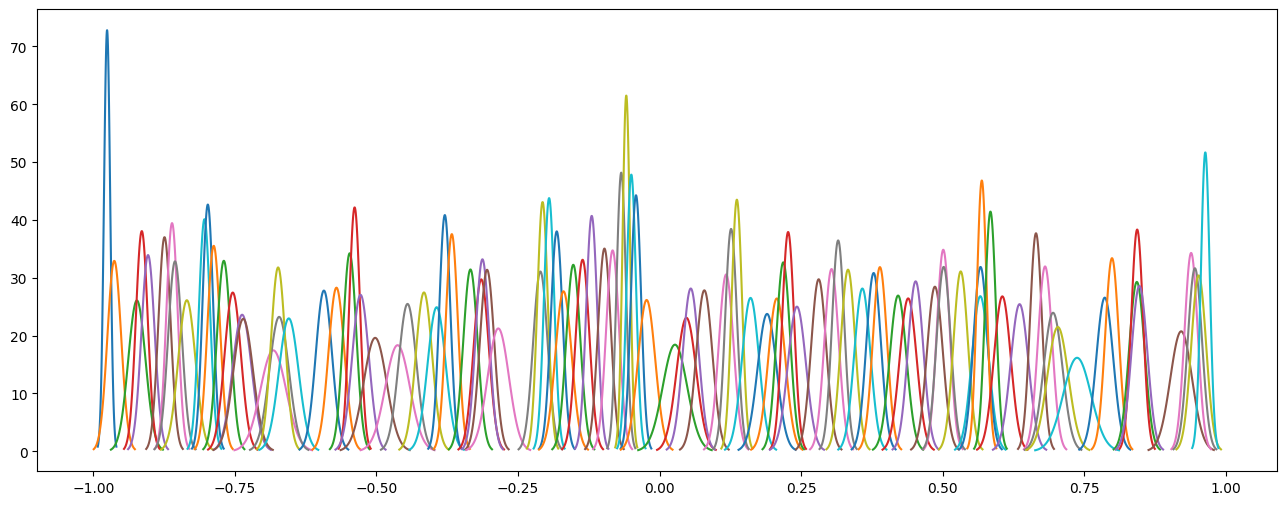

In [25]:
# Plot the gauss curves for all neurons in the SOM

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
for neuron in original_fit_som.neurons:
    x = np.linspace(neuron.preferred_value - 3 * neuron.tuning_curve_width, neuron.preferred_value + 3 * neuron.tuning_curve_width, 100)
    y = 1/(neuron.tuning_curve_width * np.sqrt(2 * np.pi)) * np.exp( - (x - neuron.preferred_value)**2 / (2 * neuron.tuning_curve_width**2))
    plt.plot(x, y)
plt.show()

C:\Users\Lutz\AppData\Local\Temp\ipykernel_11856\4237061836.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = 1/(snn_fit_som.standard_deviation[i] * np.sqrt(2 * np.pi)) * np.exp( - (x - snn_fit_som.preferred_value[i])**2 / (2 * snn_fit_som.standard_deviation[i]**2))


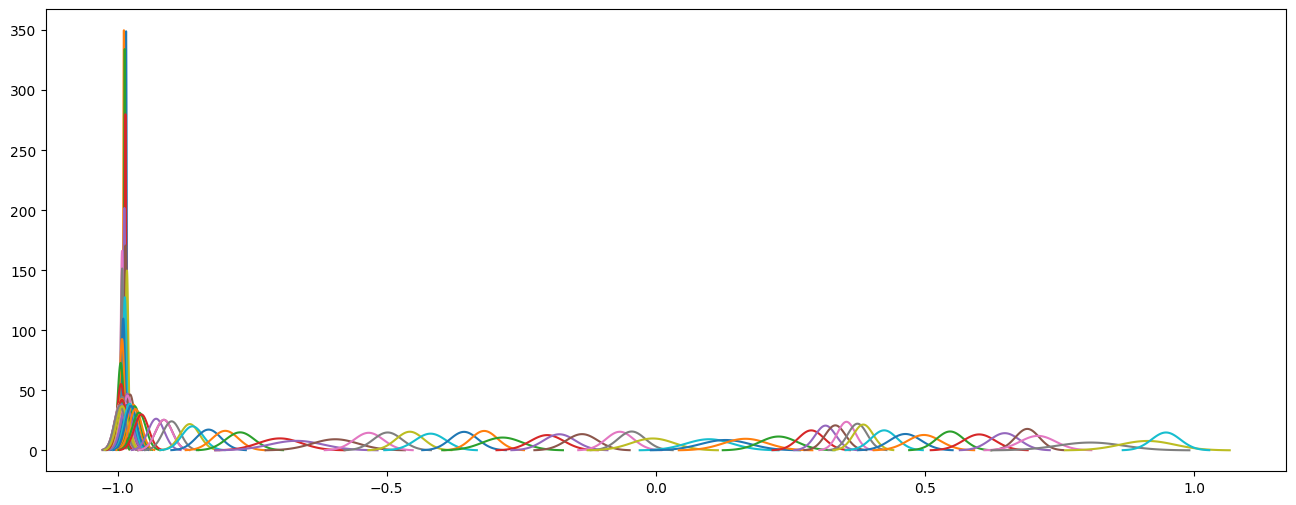

In [24]:
# For the SNN SOM
plt.figure(figsize=(16, 6))  # Adjust the width and height as needed
for i in range(len(snn_fit_som.preferred_value)):
    x = np.linspace(snn_fit_som.preferred_value[i] - 3 * snn_fit_som.standard_deviation[i], snn_fit_som.preferred_value[i] + 3 * snn_fit_som.standard_deviation[i], 100)
    y = 1/(snn_fit_som.standard_deviation[i] * np.sqrt(2 * np.pi)) * np.exp( - (x - snn_fit_som.preferred_value[i])**2 / (2 * snn_fit_som.standard_deviation[i]**2))
    plt.plot(x, y)
plt.show()